Imports

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

create and plot sample dataset

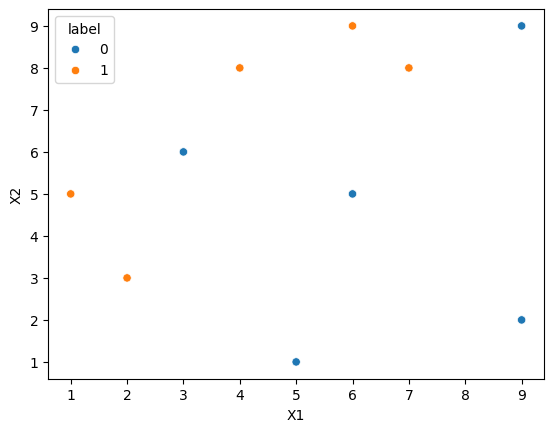

In [25]:
df = pd.DataFrame()
df['X1'] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['X2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df['label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])
plt.show()

initialize weight

In [26]:
df['weights'] = 1 / df.shape[0]
print(df)

   X1  X2  label  weights
0   1   5      1      0.1
1   2   3      1      0.1
2   3   6      0      0.1
3   4   8      1      0.1
4   5   1      0      0.1
5   6   9      1      0.1
6   6   5      0      0.1
7   7   8      1      0.1
8   9   9      0      0.1
9   9   2      0      0.1


Train the First Weak Learner

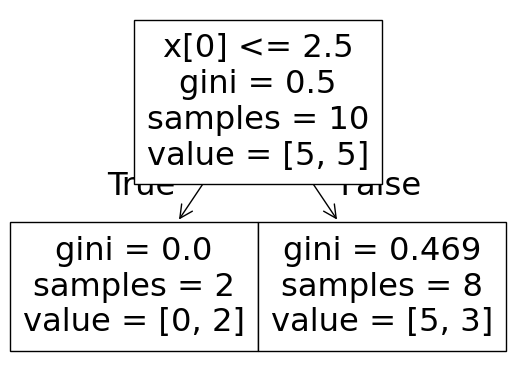

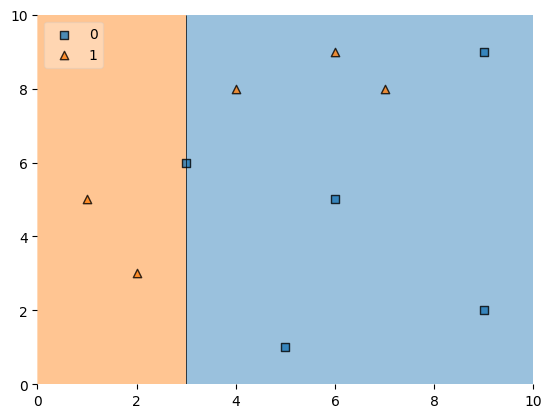

   X1  X2  label  weights  y_pred
0   1   5      1      0.1       1
1   2   3      1      0.1       1
2   3   6      0      0.1       0
3   4   8      1      0.1       0
4   5   1      0      0.1       0
5   6   9      1      0.1       0
6   6   5      0      0.1       0
7   7   8      1      0.1       0
8   9   9      0      0.1       0
9   9   2      0      0.1       0


In [27]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

dt1 = DecisionTreeClassifier(max_depth=1)
dt1.fit(X, y)

plot_tree(dt1)
plt.show()

plot_decision_regions(X, y, clf=dt1, legend=2)
plt.show()

df['y_pred'] = dt1.predict(X)
print(df)

calculate weight

In [28]:
def calculate_model_weight(error):
    return 0.5 * np.log((1 - error) / error)

error1 = 0.3
alpha1 = calculate_model_weight(error1)
alpha1

np.float64(0.42364893019360184)

update weight

In [29]:
def update_row_weights(row, alpha):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

df['updated_weights'] = df.apply(update_row_weights, alpha=alpha1, axis=1)
df

df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()

create new dataset

In [30]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']
index_values = create_new_dataset(df)
new_df = df.iloc[index_values, [0, 1, 2, 3]]
new_df

,X1,X2,label,weights
8,9,9,0,0.1
5,6,9,1,0.1
1,2,3,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
1,2,3,1,0.1
0,1,5,1,0.1


train second weak learner

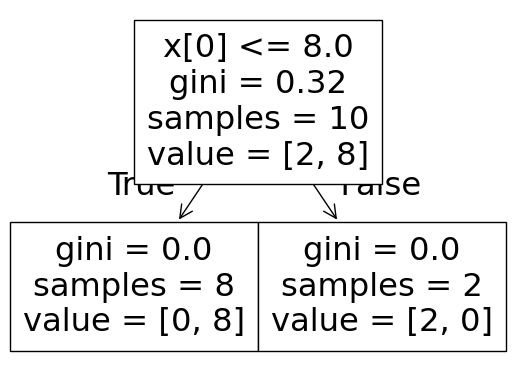

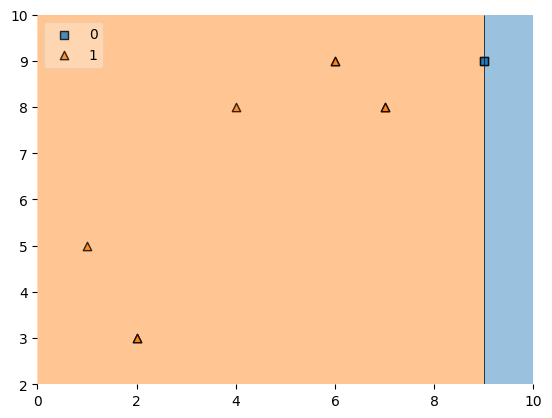

np.float64(1.0986122886681098)

In [31]:
X_new = new_df.iloc[:, 0:2].values
y_new = new_df.iloc[:, 2].values

dt2 = DecisionTreeClassifier(max_depth=1)
dt2.fit(X_new, y_new)

plot_tree(dt2)
plt.show()

plot_decision_regions(X_new, y_new, clf=dt2, legend=2)
plt.show()

new_df['y_pred'] = dt2.predict(X_new)
new_df

error2 = 0.1
alpha2 = calculate_model_weight(error2)
alpha2

update weight

In [32]:
new_df['updated_weights'] = new_df.apply(update_row_weights, alpha=alpha2, axis=1)

new_df['normalized_weights'] = new_df['updated_weights'] / new_df['updated_weights'].sum()
new_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
8,9,9,0,0.1,0,0.033333,0.1
5,6,9,1,0.1,1,0.033333,0.1
1,2,3,1,0.1,1,0.033333,0.1
7,7,8,1,0.1,1,0.033333,0.1
5,6,9,1,0.1,1,0.033333,0.1
3,4,8,1,0.1,1,0.033333,0.1
8,9,9,0,0.1,0,0.033333,0.1
7,7,8,1,0.1,1,0.033333,0.1
1,2,3,1,0.1,1,0.033333,0.1
0,1,5,1,0.1,1,0.033333,0.1


train 3rd weak learner

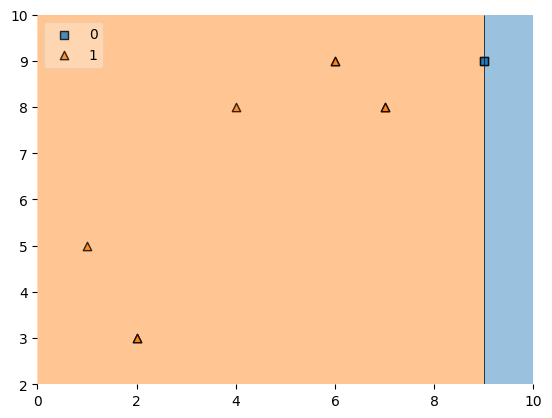

np.float64(-0.4236489301936017)

In [33]:
X_new = new_df.iloc[:, 0:2].values
y_new = new_df.iloc[:, 2].values

dt3 = DecisionTreeClassifier(max_depth=1)
dt3.fit(X_new, y_new)

plot_decision_regions(X_new, y_new, clf=dt3, legend=2)
plt.show()

new_df['y_pred'] = dt3.predict(X_new)
new_df

error3 = 0.7
alpha3 = calculate_model_weight(error3)
alpha3

final model

In [34]:
def final_prediction(query, classifiers, alphas):
    predictions = np.array([clf.predict(query) for clf in classifiers])
    final_score = np.dot(alphas, predictions)
    return np.sign(final_score)

classifiers = [dt1, dt2, dt3]
alphas = [alpha1, alpha2, alpha3]

query1 = np.array([1, 5]).reshape(1, -1)
query2 = np.array([9, 9]).reshape(1, -1)

print(final_prediction(query1, classifiers, alphas))
print(final_prediction(query2, classifiers, alphas))

[1.]
[0.]
